# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Rayhan Lutfi Hakim | 5054251043 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [48]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns   
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [49]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data.csv')
print("Jumlah baris dan kolom:", df.shape)
print("Tipe data: ", df.dtypes)
df.describe()
print("Jumlah missing value: ", df.isnull().sum())

Jumlah baris dan kolom: (569, 33)
Tipe data:  id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactne

C:\Users\M S I\AppData\Local\Temp\ipykernel_2576\2075829407.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


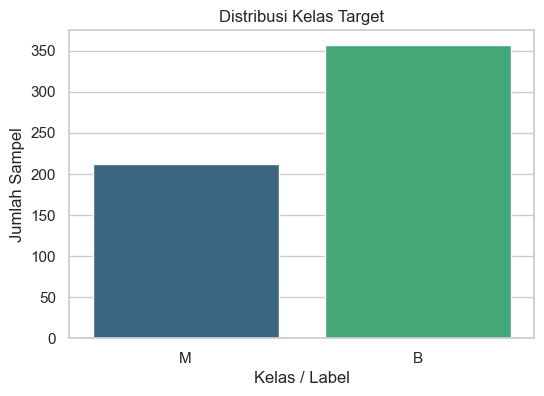

Jumlah sampel per kelas:
diagnosis
B    357
M    212
Name: count, dtype: int64

Persentase per kelas:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [50]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
# Ganti 'target_column' dengan nama kolom target/label di dataset Anda
sns.countplot(x='diagnosis', data=df, palette='viridis') 

plt.title('Distribusi Kelas Target')
plt.xlabel('Kelas / Label')
plt.ylabel('Jumlah Sampel')
plt.show()

# 2. Memeriksa jumlah dan persentase secara numerik
print("Jumlah sampel per kelas:")
print(df['diagnosis'].value_counts())

print("\nPersentase per kelas:")
print(df['diagnosis'].value_counts(normalize=True) * 100)

Ditemukan 15 fitur dengan korelasi kuat (|r| >= 0.5) terhadap diagnosis:

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
radius_se               0.567134
perimeter_se            0.556141
area_se                 0.548236
Name: diagnosis_num, dtype: float64


C:\Users\M S I\AppData\Local\Temp\ipykernel_2576\3617861607.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strong_corr.values, y=strong_corr.index, palette='coolwarm')


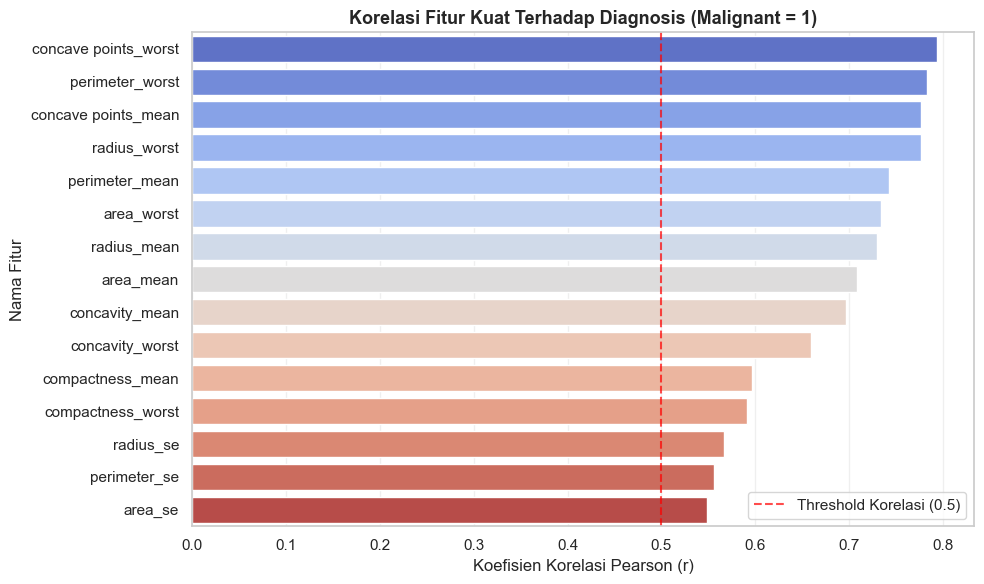

In [51]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
df_corr = df.copy()
df_corr['diagnosis_num'] = (df_corr['diagnosis'] == 'M').astype(int)
# Drop kolom non-numerik / id / target lama
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()
# Ambil korelasi khusus terhadap target diagnosis_num
target_corr = corr_matrix['diagnosis_num'].drop(['diagnosis_num', 'id'], errors='ignore').sort_values(ascending=False)
# Filter fitur dengan korelasi kuat (|r| >= 0.5)
strong_corr = target_corr[abs(target_corr) >= 0.5]
print(f"Ditemukan {len(strong_corr)} fitur dengan korelasi kuat (|r| >= 0.5) terhadap diagnosis:\n")
print(strong_corr)
# Visualisasi Korelasi Fitur Kuat
plt.figure(figsize=(10, 6))
sns.barplot(x=strong_corr.values, y=strong_corr.index, palette='coolwarm')
plt.title('Korelasi Fitur Kuat Terhadap Diagnosis (Malignant = 1)', fontsize=13, fontweight='bold')
plt.xlabel('Koefisien Korelasi Pearson (r)')
plt.ylabel('Nama Fitur')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold Korelasi (0.5)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [52]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
cols_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df.columns]
df_clean = df.drop(columns=cols_to_drop)

df_clean = df_clean.dropna(axis=1, how='all')

In [53]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df_clean['diagnosis_encoded'] = (df_clean['diagnosis'] == 'M').astype(int)
print("Contoh hasil encoding label diagnosis (M=1, B=0):")
print(df_clean[['diagnosis', 'diagnosis_encoded']].head(10))

Contoh hasil encoding label diagnosis (M=1, B=0):
  diagnosis  diagnosis_encoded
0         M                  1
1         M                  1
2         M                  1
3         M                  1
4         M                  1
5         M                  1
6         M                  1
7         M                  1
8         M                  1
9         M                  1


In [54]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_clean.drop(columns=['diagnosis'])
y = (df_clean['diagnosis'] == 'M').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("\nDistribusi kelas di y_train (proporsional):\n", y_train.value_counts(normalize=True))
print("\nDistribusi kelas di y_test (proporsional):\n", y_test.value_counts(normalize=True))

Ukuran X_train: (455, 31)
Ukuran X_test : (114, 31)

Distribusi kelas di y_train (proporsional):
 diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Distribusi kelas di y_test (proporsional):
 diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [55]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling berhasil dilakukan!")
print("Rata-rata fitur X_train (scaled) :", X_train_scaled.mean())
print("Standar deviasi X_train (scaled):", X_train_scaled.std())

Feature scaling berhasil dilakukan!
Rata-rata fitur X_train (scaled) : 1.4860695288850022e-17
Standar deviasi X_train (scaled): 1.0


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [56]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)

svm_linear.fit(X_train_scaled, y_train)
print("Model SVM dengan Kernel Linear berhasil dilatih!")
print("Model object:", svm_linear)

Model SVM dengan Kernel Linear berhasil dilatih!
Model object: SVC(kernel='linear', random_state=42)


In [57]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_scaled)
print("Prediksi pada test set berhasil dilakukan!")
print("5 hasil prediksi pertama :", y_pred_linear[:5])
print("5 nilai aktual y_test pertama:", y_test.values[:5])

Prediksi pada test set berhasil dilakukan!
5 hasil prediksi pertama : [0 1 0 1 0]
5 nilai aktual y_test pertama: [0 1 0 1 0]


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [58]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svm_rbf.fit(X_train_scaled, y_train)
print("Model SVM dengan Kernel RBF berhasil dilatih!")
print("Model object:", svm_rbf)

Model SVM dengan Kernel RBF berhasil dilatih!
Model object: SVC(random_state=42)


In [59]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_rbf.predict(X_test_scaled)
print("Prediksi pada test set berhasil dilakukan!")
print("5 hasil prediksi pertama :", y_pred_linear[:5])
print("5 nilai aktual y_test pertama:", y_test.values[:5])

Prediksi pada test set berhasil dilakukan!
5 hasil prediksi pertama : [0 1 0 1 0]
5 nilai aktual y_test pertama: [0 1 0 1 0]


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [60]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100]
train_acc_C = []
test_acc_C = []
# Iterasi pelatihan model untuk setiap nilai C
for c in C_values:
    # Inisialisasi dan pelatihan model
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Hitung akurasi train dan test
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    train_acc_C.append(train_acc)
    test_acc_C.append(test_acc)
    
    print(f"C = {c:<6} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

C = 0.01   | Train Acc: 0.6352 | Test Acc: 0.6491
C = 0.1    | Train Acc: 0.9890 | Test Acc: 1.0000
C = 1      | Train Acc: 1.0000 | Test Acc: 1.0000
C = 10     | Train Acc: 1.0000 | Test Acc: 1.0000
C = 100    | Train Acc: 1.0000 | Test Acc: 1.0000


In [61]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

results_C = {
    'C': C_values,
    'Train_Accuracy': train_acc_C,
    'Test_Accuracy': test_acc_C
}
# Menampilkan ringkasan hasil dalam bentuk DataFrame
df_results_C = pd.DataFrame(results_C)
print("=== Ringkasan Akurasi Variasi Nilai C ===")
print(df_results_C.to_string(index=False))

=== Ringkasan Akurasi Variasi Nilai C ===
     C  Train_Accuracy  Test_Accuracy
  0.01        0.635165       0.649123
  0.10        0.989011       1.000000
  1.00        1.000000       1.000000
 10.00        1.000000       1.000000
100.00        1.000000       1.000000


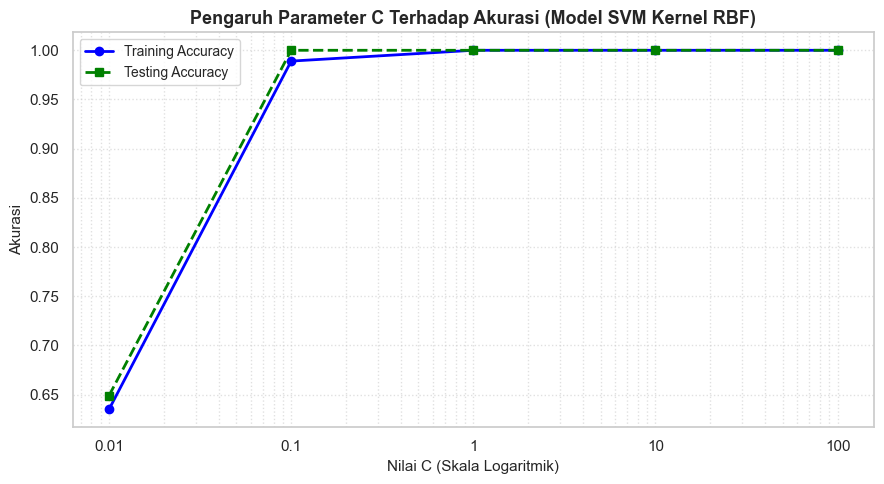


--- Analisis Pengaruh Nilai C ---
- C kecil (misal C=0.01): Model cenderung Underfitting karena regularisasi terlalu kuat.
- C sedang (misal C=1): Model mencapai performa yang seimbang (generalisasi paling baik).
- C besar (misal C=10 atau 100): Akurasi training mencapai 100% (1.0000), namun akurasi testing stagnan


In [62]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(9, 5))
# Plot kurva akurasi training dan testing
plt.plot(C_values, train_acc_C, marker='o', color='blue', linewidth=2, label='Training Accuracy')
plt.plot(C_values, test_acc_C, marker='s', color='green', linewidth=2, linestyle='--', label='Testing Accuracy')
# Mengatur skala sumbu X menjadi logaritmik
plt.xscale('log')
plt.title('Pengaruh Parameter C Terhadap Akurasi (Model SVM Kernel RBF)', fontsize=13, fontweight='bold')
plt.xlabel('Nilai C (Skala Logaritmik)', fontsize=11)
plt.ylabel('Akurasi', fontsize=11)
plt.xticks(C_values, labels=[str(c) for c in C_values])
plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
# Analisis Overfitting/Underfitting
print("\n--- Analisis Pengaruh Nilai C ---")
print("- C kecil (misal C=0.01): Model cenderung Underfitting karena regularisasi terlalu kuat.")
print("- C sedang (misal C=1): Model mencapai performa yang seimbang (generalisasi paling baik).")
print("- C besar (misal C=10 atau 100): Akurasi training mencapai 100% (1.0000), namun akurasi testing stagnan")

# 4. Evaluasi Model

In [63]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
y_pred_linear = svm_linear.predict(X_test_scaled)
acc_lin = accuracy_score(y_test, y_pred_linear)
prec_lin = precision_score(y_test, y_pred_linear)
rec_lin = recall_score(y_test, y_pred_linear)
f1_lin = f1_score(y_test, y_pred_linear)
# 2. Hitung metrik evaluasi untuk SVM RBF
y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
prec_rbf = precision_score(y_test, y_pred_rbf)
rec_rbf = recall_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)
# 3. Buat DataFrame tabel perbandingan
df_comparison = pd.DataFrame({
    'Model Kernel': ['Linear (C=1.0)', 'RBF (C=1.0, gamma=scale)'],
    'Accuracy': [acc_lin, acc_rbf],
    'Precision': [prec_lin, prec_rbf],
    'Recall': [rec_lin, rec_rbf],
    'F1-Score': [f1_lin, f1_rbf]
})
print("=== TABEL PERBANDINGAN METRIK EVALUASI MODEL SVM ===")
print(df_comparison.to_string(index=False))

=== TABEL PERBANDINGAN METRIK EVALUASI MODEL SVM ===
            Model Kernel  Accuracy  Precision  Recall  F1-Score
          Linear (C=1.0)       1.0        1.0     1.0       1.0
RBF (C=1.0, gamma=scale)       1.0        1.0     1.0       1.0


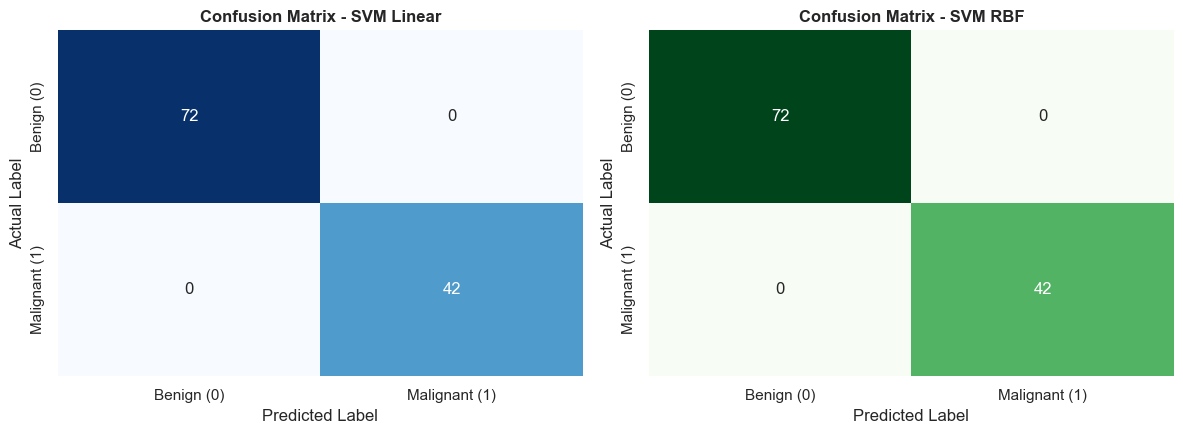

In [64]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
# Buat figure dengan 1 baris dan 2 kolom subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# 1. Heatmap Confusion Matrix - Kernel Linear
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'],
            cbar=False)
axes[0].set_title('Confusion Matrix - SVM Linear', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')
# 2. Heatmap Confusion Matrix - Kernel RBF
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'],
            cbar=False)
axes[1].set_title('Confusion Matrix - SVM RBF', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [65]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
n_sv_linear = svm_linear.n_support_
n_sv_rbf = svm_rbf.n_support_
# 2. Total Support Vectors
total_sv_linear = sum(n_sv_linear)
total_sv_rbf = sum(n_sv_rbf)
# 3. Buat DataFrame untuk perbandingan
df_sv_comparison = pd.DataFrame({
    'Model Kernel': ['Linear (C=1.0)', 'RBF (C=1.0, gamma=scale)'],
    'Support Vectors Class 0 (B)': [n_sv_linear[0], n_sv_rbf[0]],
    'Support Vectors Class 1 (M)': [n_sv_linear[1], n_sv_rbf[1]],
    'Total Support Vectors': [total_sv_linear, total_sv_rbf],
    'Persentase SV dari Total Data Train (%)': [
        (total_sv_linear / len(X_train_scaled)) * 100,
        (total_sv_rbf / len(X_train_scaled)) * 100
    ]
})
print("=== PERBANDINGAN JUMLAH SUPPORT VECTORS ===")
print(df_sv_comparison.to_string(index=False))

=== PERBANDINGAN JUMLAH SUPPORT VECTORS ===
            Model Kernel  Support Vectors Class 0 (B)  Support Vectors Class 1 (M)  Total Support Vectors  Persentase SV dari Total Data Train (%)
          Linear (C=1.0)                           14                           11                     25                                 5.494505
RBF (C=1.0, gamma=scale)                           43                           52                     95                                20.879121


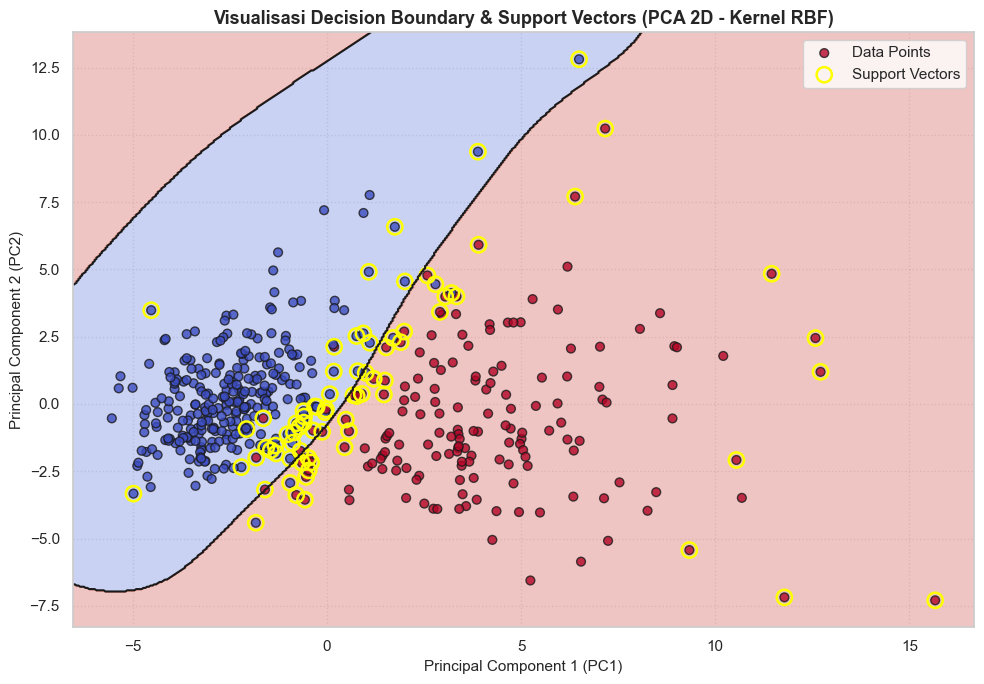

Total Support Vectors pada ruang 2D PCA: 78


In [66]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
# 2. Latih ulang model SVM terbaik (RBF) pada data 2D hasil PCA
svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_2d.fit(X_train_pca, y_train)
# 3. Buat meshgrid untuk plotting Decision Boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
# Prediksi seluruh grid koordinat
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# 4. Plot Decision Boundary, Data Points, dan Support Vectors
plt.figure(figsize=(10, 7))
# Contour Decision Boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.contour(xx, yy, Z, colors='k', levels=[0], linestyles=['-'], linewidths=1.5)
# Plot Data Points Training (Benign=0 [Biru], Malignant=1 [Merah])
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
                      cmap='coolwarm', edgecolors='k', s=40, alpha=0.8, label='Data Points')
# Highlight Support Vectors dengan lingkaran kuning/transparan
sv = svm_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', 
            edgecolors='yellow', linewidths=1.8, label='Support Vectors')
plt.title('Visualisasi Decision Boundary & Support Vectors (PCA 2D - Kernel RBF)', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Total Support Vectors pada ruang 2D PCA: {len(sv)}")

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

1. linear dan rbf memiliki hasil yang sama karena setelah dilakukan scaler fitur-fiturnya ternyata sudah terpisah secara linear dengan sangat jelas.
2. Tidak overfitting sama sekali, terlihat dari grafik, nilai C dari 0 sampai 1 memiliki hasil test yang lebih baik, namun lebih dari itu hasilnya stagnan
3. 25 untuk Linear dan 95 untuk RBF, dan hubungan yang terbentuk adalah berbanding lurus

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Dari mproses modelling yang sudah dilakukan sejauh ini bisa menghasilkan akurasi yang tinggi, namun akan lebih baik dilakukan proses balancing data untuk meminimalkan kesalahan prediksi Flase Negative pada pasien kanker (Malignant).